# Effect of Noise and Comparison of Different Denoising Methods in MRI Imaging 

In [2]:
# set up: 
%pip install nibabel

import nibabel as nib 
import numpy as np 
import matplotlib.pyplot as plt 


Note: you may need to restart the kernel to use updated packages.


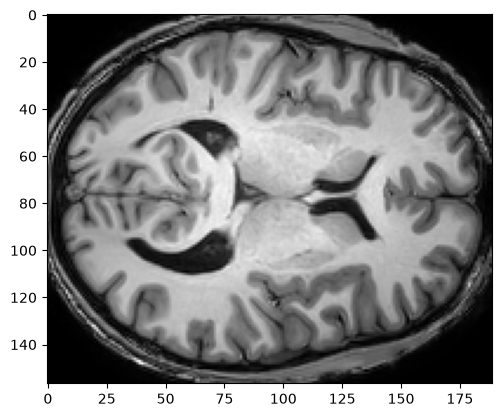

In [3]:
img = nib.load('/Users/annie/Desktop/Med Phys Research /miniproject_noise&denoising/sub-01_ses-01_T1w.nii')

data = img.get_fdata()

plt.imshow(data[:,:,data.shape[2]//2], cmap='gray')
plt.show()



## add noise to the image 

1. adding noise to original image to form a noisy image, to show that noise (randomness) is able to affect MRI image quality. 

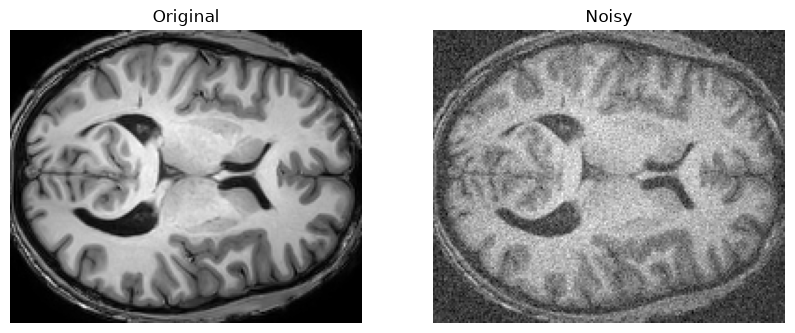

In [4]:
Gaussian_noise = np.random.normal(0, 5000, data.shape)
noise_data = data + Gaussian_noise

slice_num = data.shape[2] // 2
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(data[:,:,slice_num], cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(noise_data[:,:,slice_num], cmap='gray')
axes[1].set_title('Noisy')
axes[1].axis('off')

plt.show()

original = data[:,:,slice_num]
noisy = noise_data[:,:,slice_num]


- when standard deviation in Gaussian noise is around 3000, there is clear visual noticeable difference between the noisy image and the original image. 

In [5]:
%pip install scikit-image
from skimage.metrics import structural_similarity as ssim

ssim_value = ssim(
    original,
    noisy,
    data_range=noisy.max() - noisy.min()
)
print ("SSIM:", ssim_value)

Note: you may need to restart the kernel to use updated packages.
SSIM: 0.6360610856843851


 this noisy image (with Gaussian noise added at standard deviation = 5000) will be the noisy image used for later reference. 

- as noise randomness increases, the image quality will decrease. 

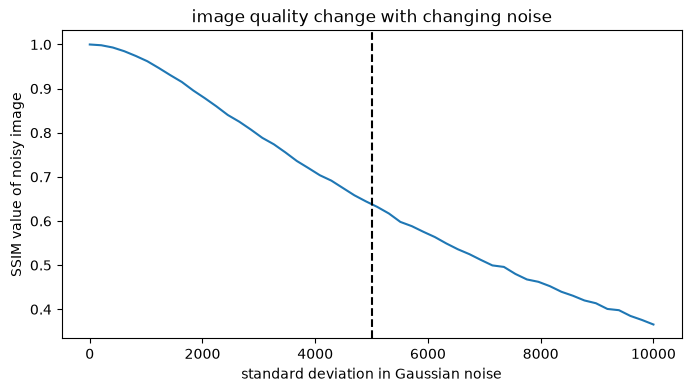

In [6]:
# c_noise = changing noise 
c_noise_sigma = np.linspace(1,10000,50)
c_ssim =[]
for s in c_noise_sigma:
    c_noise = np.random.normal(0,s,data.shape)
    c_noise_data = data + c_noise
    c_noisy = c_noise_data[:,:,slice_num]
    c_ssim_value = ssim(
        original,
        c_noisy,
    data_range=noisy.max() - noisy.min()
    )
    c_ssim.append(c_ssim_value)

plt.figure(figsize=(8,4))
plt.plot(c_noise_sigma,c_ssim)
plt.axvline(x=5000, color='k', linestyle='--')
plt.xlabel("standard deviation in Gaussian noise")
plt.ylabel("SSIM value of noisy image")
plt.title("image quality change with changing noise")
plt.show()


The SSIM of image decreases as standard deviation in Gaussian noise increases, showing as noise intensity increases, image quality decreases. 

# Denoise

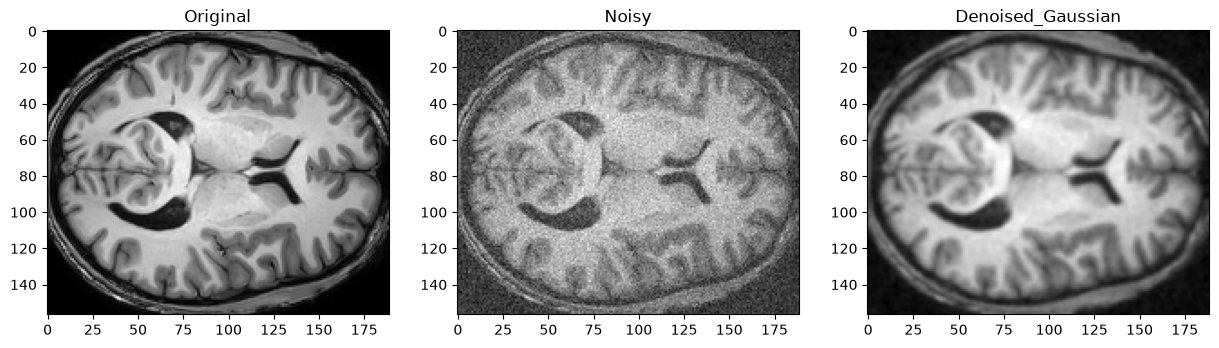

In [7]:
# Gaussian filter:
from scipy.ndimage import gaussian_filter
denoised_Gaussian = gaussian_filter(noise_data, sigma=1)

# show images:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(data[:,:,slice_num], cmap='gray')
axes[0].set_title('Original')

axes[1].imshow(noise_data[:,:,slice_num], cmap='gray')
axes[1].set_title('Noisy')

axes[2].imshow(denoised_Gaussian[:,:,slice_num], cmap='gray')
axes[2].set_title('Denoised_Gaussian')


plt.show()

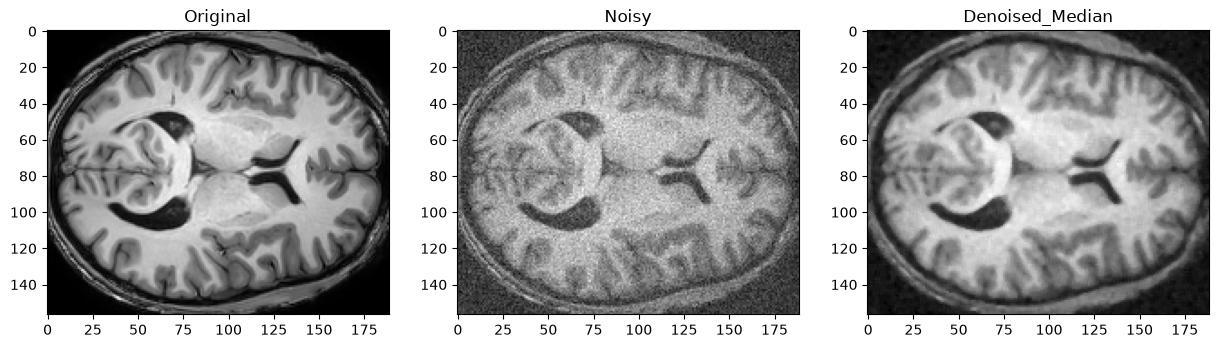

In [8]:
# Median filter:
from scipy.ndimage import median_filter
denoised_median = median_filter(noise_data, size=3)

# show images:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(data[:,:,slice_num], cmap='gray')
axes[0].set_title('Original')

axes[1].imshow(noise_data[:,:,slice_num], cmap='gray')
axes[1].set_title('Noisy')

axes[2].imshow(denoised_median[:,:,slice_num], cmap='gray')
axes[2].set_title('Denoised_Median')

plt.show()

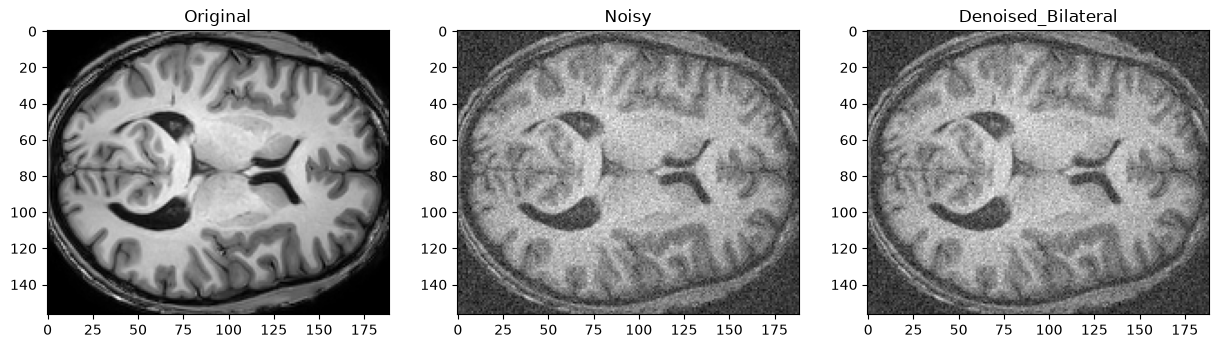

In [9]:
# bilateral filter:
from skimage.restoration import denoise_bilateral
denoised_bilateral = denoise_bilateral(
    noisy, 
    sigma_color=1.0, 
    sigma_spatial=100
)

# show images:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(data[:,:,slice_num], cmap='gray')
axes[0].set_title('Original')

axes[1].imshow(noise_data[:,:,slice_num], cmap='gray')
axes[1].set_title('Noisy')

axes[2].imshow(denoised_bilateral, cmap='gray')
axes[2].set_title('Denoised_Bilateral')
# denoised_bilateral is already 2D. 

plt.show()

Text(0.5, 1.0, 'Denoised_Bilateral')

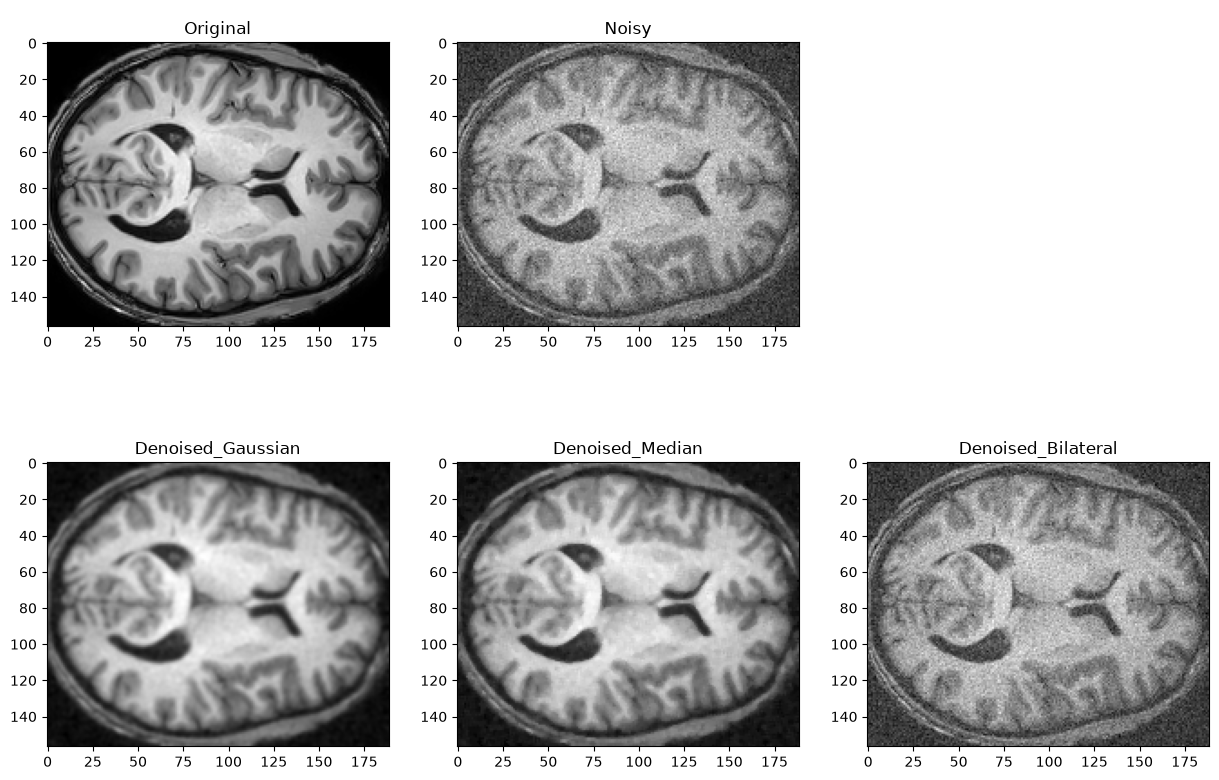

In [10]:
fig,axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(data[:,:,slice_num], cmap='gray')
axes[0, 0].set_title('Original')
axes[0, 1].imshow(noise_data[:,:,slice_num], cmap='gray')
axes[0, 1].set_title('Noisy')
axes[0, 2].axis('off') 

axes[1, 0].imshow(denoised_Gaussian[:,:,slice_num], cmap='gray')
axes[1, 0].set_title('Denoised_Gaussian')  
axes[1, 1].imshow(denoised_median[:,:,slice_num], cmap='gray')
axes[1, 1].set_title('Denoised_Median')
axes[1, 2].imshow(denoised_bilateral, cmap='gray')
axes[1, 2].set_title('Denoised_Bilateral')

shape: (157, 189, 156)


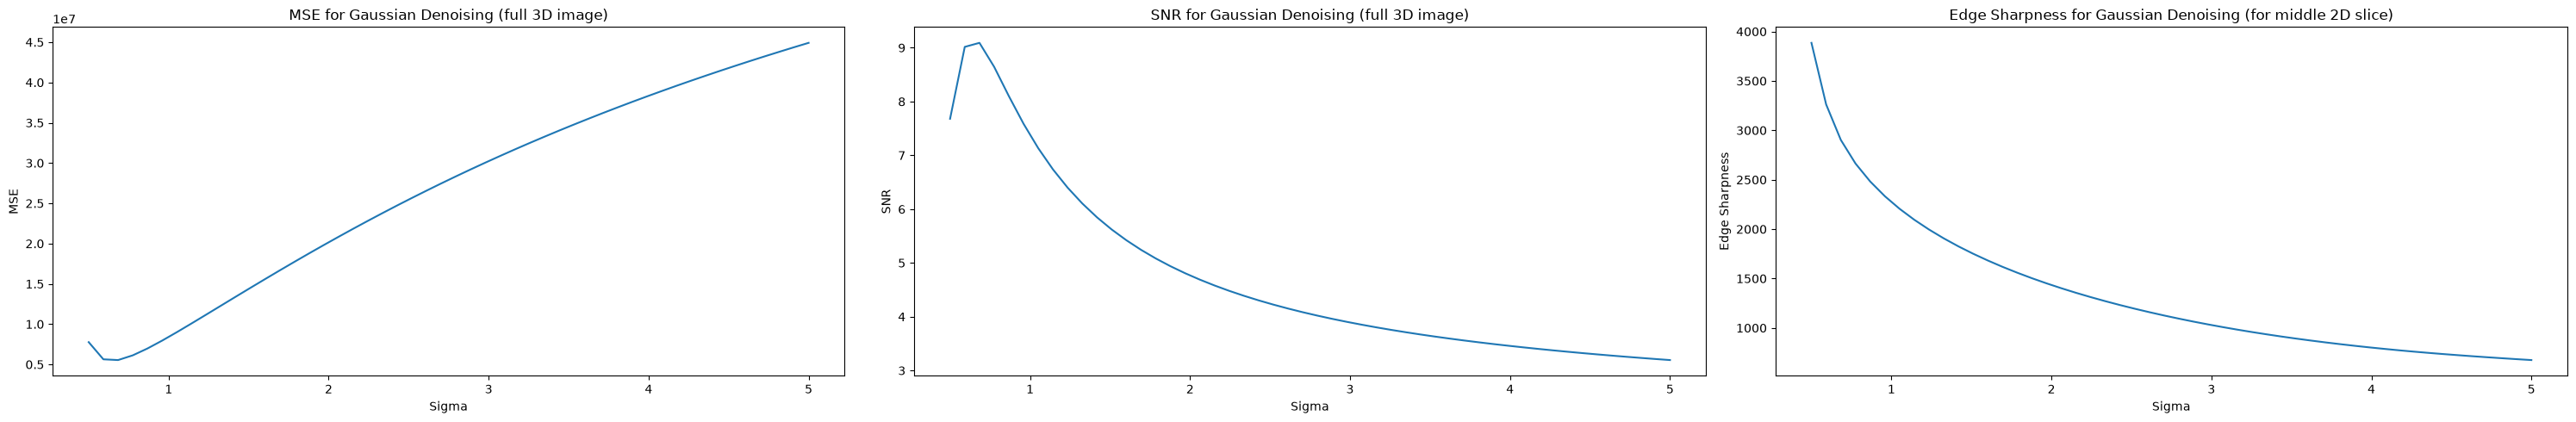

In [11]:
# effect of Gaussian filter: 

from scipy.ndimage import gaussian_filter
from skimage.metrics import mean_squared_error

sigmas = np.linspace(0.5, 5.0, 50)
mse_gaussian = []
snr_gaussian = []
edge_gaussian = []
def edge_sharpness(image):
    grad_x, grad_y = np.gradient(image)
    gradient_magnitude = np.sqrt(grad_x**2 + grad_y**2)
    
    return np.mean(gradient_magnitude)

for s in sigmas:
    denoised_gaussian = gaussian_filter(noise_data, sigma=s)
    denoised_gaussian_2D = denoised_gaussian[:,:,slice_num]
    original_2D = original
    mse_gaussian.append(mean_squared_error(data, denoised_gaussian))
    snr_gaussian.append(np.mean(original) / np.std(denoised_gaussian - data))
    edge_gaussian.append(edge_sharpness(denoised_gaussian_2D))
print ("shape:",np.shape(denoised_gaussian))

fig,axes = plt.subplots(1,3,figsize=(30,5))
axes[0].plot(sigmas,mse_gaussian)
axes[0].set_title("MSE for Gaussian Denoising (full 3D image)")
axes[0].set_xlabel("Sigma")
axes[0].set_ylabel("MSE")

axes[1].plot(sigmas,snr_gaussian)
axes[1].set_title("SNR for Gaussian Denoising (full 3D image)")
axes[1].set_xlabel("Sigma")
axes[1].set_ylabel("SNR")

axes[2].plot(sigmas,edge_gaussian)
axes[2].set_title("Edge Sharpness for Gaussian Denoising (for middle 2D slice)")
axes[2].set_xlabel("Sigma")
axes[2].set_ylabel("Edge Sharpness")

plt.tight_layout()
plt.show()



shape: (157, 189, 156)


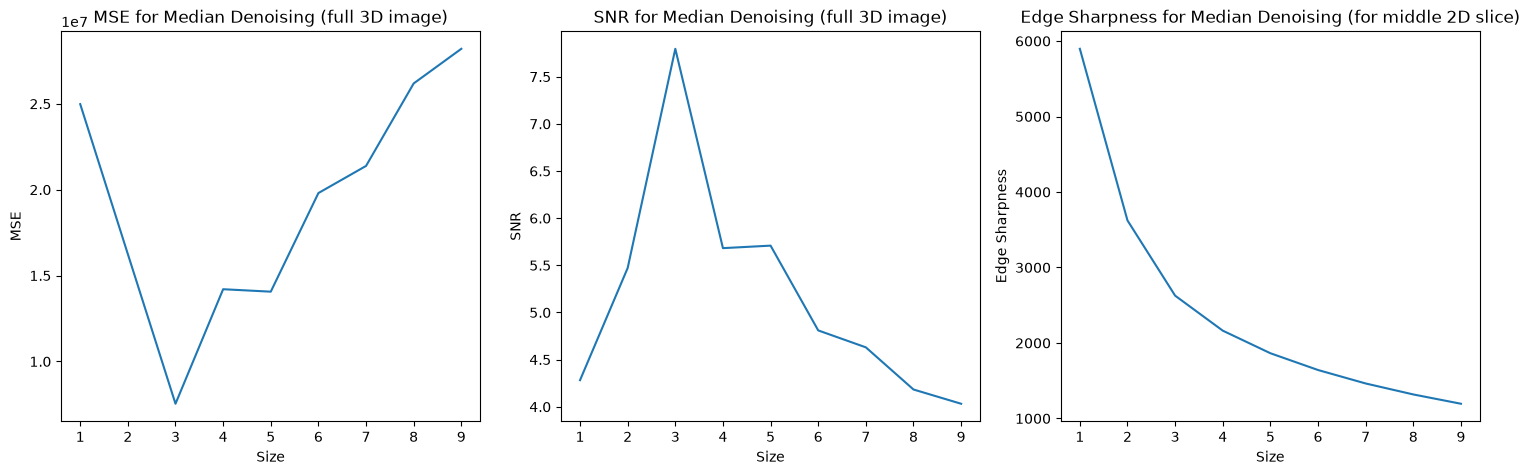

In [12]:
# Effect of Median filter:
from scipy.ndimage import median_filter
from skimage.metrics import mean_squared_error

sizes = np.arange(1, 10)
mse_median = []
snr_median = []
edge_median = []
def edge_sharpness(image):
    grad_x, grad_y = np.gradient(image)
    gradient_magnitude = np.sqrt(grad_x**2 + grad_y**2)
    return np.mean(gradient_magnitude)

for s in sizes:
    denoised_median = median_filter(noise_data, size=s)
    denoised_median_2D = denoised_median[:,:,slice_num]
    mse_median.append(mean_squared_error(data, denoised_median))
    snr_median.append(np.mean(original) / np.std(denoised_median - data))
    edge_median.append(edge_sharpness(denoised_median_2D))

print ("shape:",np.shape(denoised_median))
fig,axes = plt.subplots(1,3,figsize=(15,5))
axes[0].plot(sizes,mse_median)
axes[0].set_title("MSE for Median Denoising (full 3D image)")
axes[0].set_xlabel("Size")
axes[0].set_ylabel("MSE")

axes[1].plot(sizes,snr_median)
axes[1].set_title("SNR for Median Denoising (full 3D image)")
axes[1].set_xlabel("Size")
axes[1].set_ylabel("SNR")

axes[2].plot(sizes,edge_median)
axes[2].set_title("Edge Sharpness for Median Denoising (for middle 2D slice)")
axes[2].set_xlabel("Size")
axes[2].set_ylabel("Edge Sharpness")

plt.tight_layout()
plt.show()

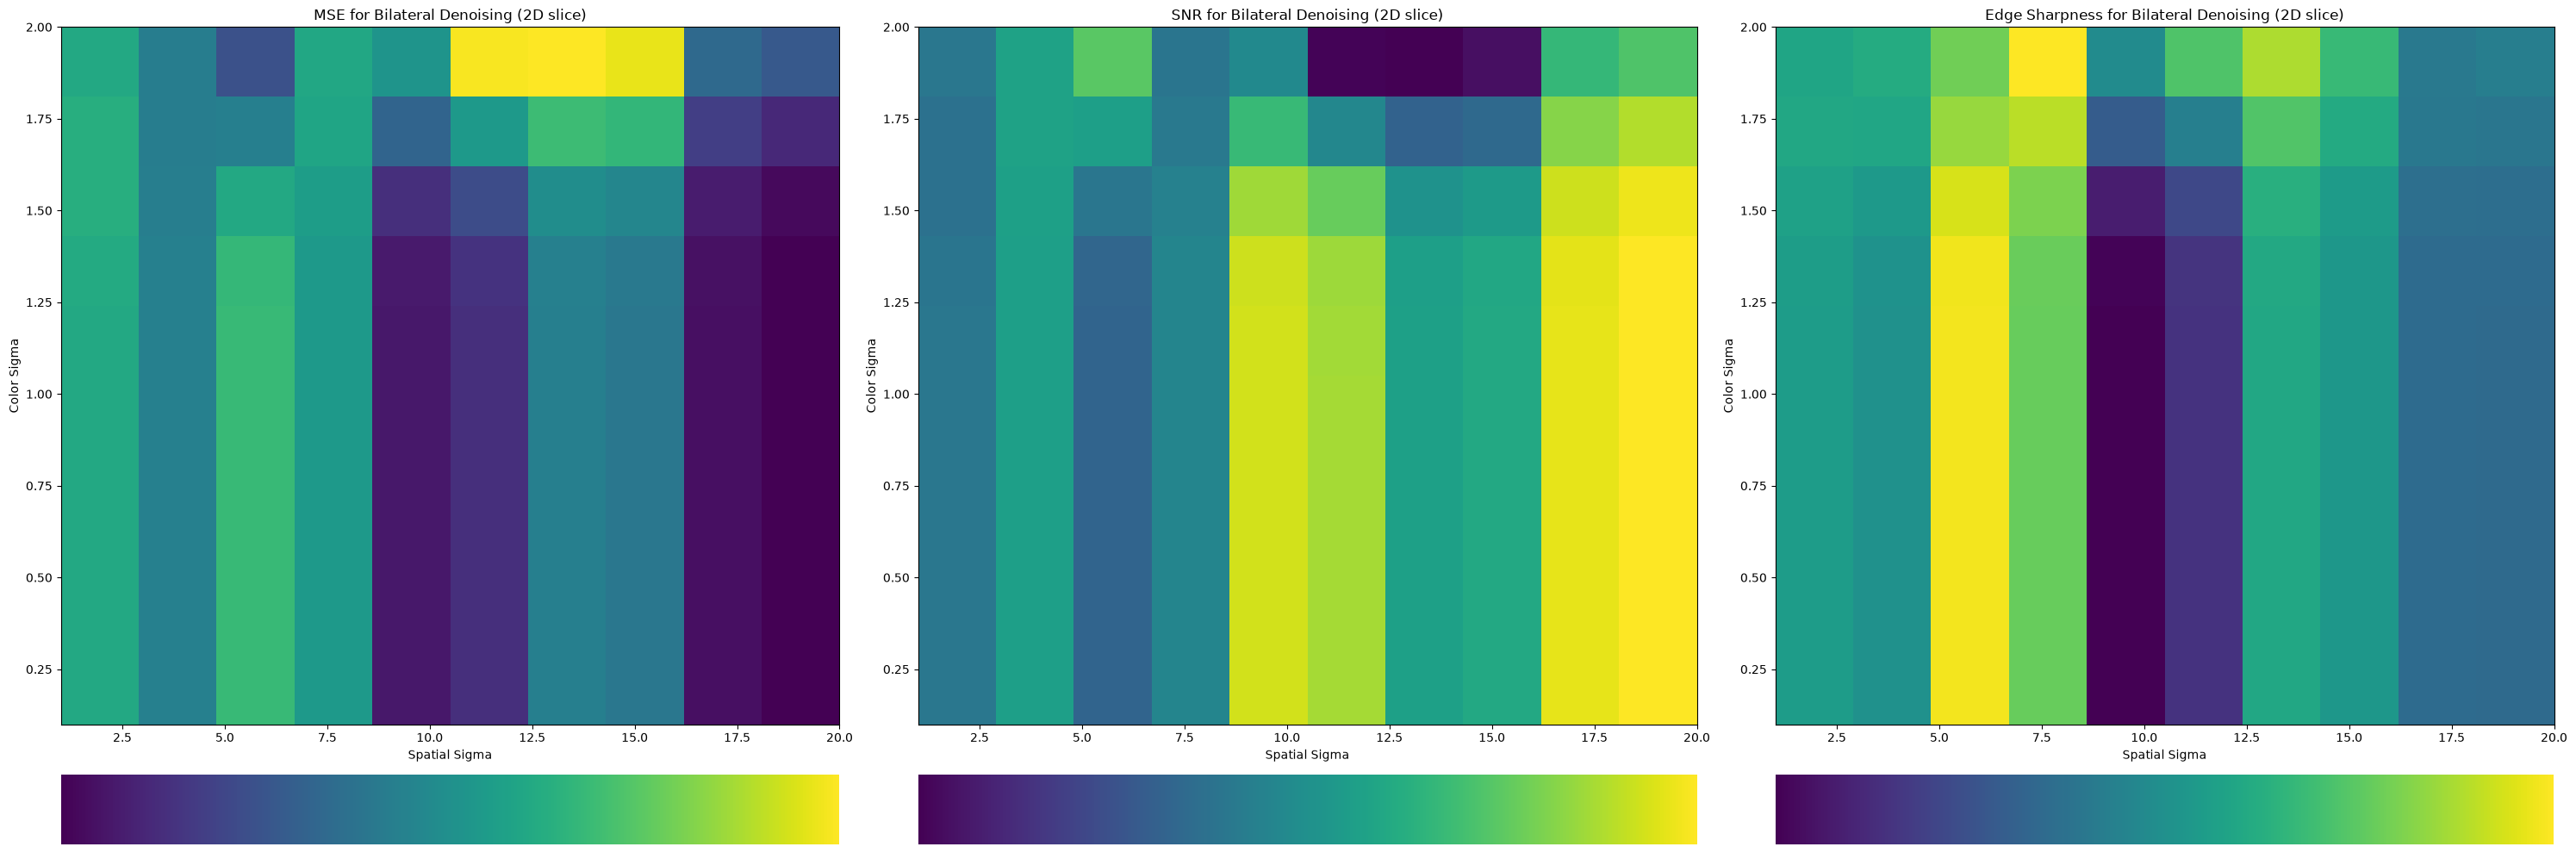

In [15]:
# Effect of Bilateral Filter: 

from skimage.restoration import denoise_bilateral 

color = np.linspace(0.1, 2.0, 10)
spatial = np.linspace(1, 20, 10)
# inclusive 

M_mse = np.zeros((len(color), len(spatial)))
M_snr = np.zeros((len(color), len(spatial)))
M_edge = np.zeros((len(color), len(spatial)))

for i,c in enumerate(color):
    for j,s in enumerate(spatial):
        denoised_bilateral = denoise_bilateral(
            noisy, 
            sigma_color=c, 
            sigma_spatial=s 
        )
        M_mse[i,j] = mean_squared_error(original, denoised_bilateral)
        M_snr[i,j] = np.mean(original) / np.std(denoised_bilateral - original)
        M_edge[i,j] = edge_sharpness(denoised_bilateral)

fig,axes = plt.subplots(2,3,figsize=(30,10),
                        gridspec_kw={'height_ratios':[10,1]})
axes[0,0].imshow(
    M_mse,
    aspect='auto',
    origin='lower',
    extent=[spatial.min(),spatial.max(),color.min(),color.max()],
    cmap='viridis'
)
axes[0,0].set_title("MSE for Bilateral Denoising (2D slice)")
axes[0,0].set_xlabel("Spatial Sigma")
axes[0,0].set_ylabel("Color Sigma")   

axes[0,1].imshow(
    M_snr,
    aspect='auto',
    origin='lower',
    extent=[spatial.min(),spatial.max(),color.min(),color.max()],
    cmap='viridis'
)
axes[0,1].set_title("SNR for Bilateral Denoising (2D slice)")
axes[0,1].set_xlabel("Spatial Sigma")
axes[0,1].set_ylabel("Color Sigma") 

axes[0,2].imshow(
    M_edge,
    aspect='auto',
    origin='lower',
    extent=[spatial.min(),spatial.max(),color.min(),color.max()],
    cmap='viridis'
)
axes[0,2].set_title("Edge Sharpness for Bilateral Denoising (2D slice)")
axes[0,2].set_xlabel("Spatial Sigma")
axes[0,2].set_ylabel("Color Sigma") 

im_mse = axes[0,0].imshow(M_mse, aspect='auto', origin='lower', extent=[spatial.min(), spatial.max(), color.min(), color.max()], cmap='viridis')
im_snr = axes[0,1].imshow(M_snr, aspect='auto', origin='lower', extent=[spatial.min(), spatial.max(), color.min(), color.max()], cmap='viridis')
im_edge = axes[0,2].imshow(M_edge, aspect='auto', origin='lower', extent=[spatial.min(), spatial.max(), color.min(), color.max()], cmap='viridis')

for ax in axes[1,:]:
    ax.set_axis_off()
plt.colorbar(im_mse, cax=axes[1,0], orientation='horizontal', label='MSE colorbar')
plt.colorbar(im_snr, cax=axes[1,1], orientation='horizontal', label='SNR colorbar')
plt.colorbar(im_edge, cax=axes[1,2], orientation='horizontal', label='Edge Sharpness colorbar')

plt.tight_layout()
plt.show()


In [14]:
print("MSE max:", np.max(M_mse))
print("SNR max:", np.max(M_snr))
print("Edge sharpness max:", np.max(M_edge))

print("MSE min:", np.min(M_mse))
print("SNR min:", np.min(M_snr))
print("Edge sharpness min:", np.min(M_edge))

MSE max: 25048291.646032106
SNR max: 4.276930945590688
Edge sharpness max: 5897.030221667322
MSE min: 25048024.903555043
SNR min: 4.276908097774223
Edge sharpness min: 5897.002983883083
